## mlpi26_Lect07_nbsup1.ipynb 
# Lecture 7 Supplement 1 : Neural network fundamentals with PyTorch
## Running example: learning the inverse dynamics of a 2-link robot arm

A robot controller has to answer one question a thousand times a second: *given where the joints
are, how fast they are moving and how fast I want them to accelerate, what torque should each
motor produce?* That map is the **inverse dynamics** of the arm,

$$\tau \;=\; M(q)\,\ddot q \;+\; C(q,\dot q)\,\dot q \;+\; g(q) \;+\; f(\dot q)$$

For a rigid two-link arm you can write it down by hand. For a real arm with belts, harmonic
drives, cable routing and joint flexibility, you cannot — but you *can* log the states and the
measured torques and learn the map. That is exactly what this notebook does, and it is a real,
widely used application of neural networks in robotics.

### Learning objectives

By the end you will be able to

1. explain what a **multilayer perceptron (MLP)** is and why the activation function is the whole
   point of it;
2. derive and hand-code the **backpropagation** equations for a one-hidden-layer network, and
   check them against PyTorch;
3. create, reshape and move **`torch.Tensor`** objects, and read a shape error;
4. use **autograd** — `requires_grad`, `.backward()`, `.grad`, `torch.no_grad()` — and say what
   `optimizer.zero_grad()` is protecting you from;
5. wrap data in a **`Dataset`** and iterate it with a **`DataLoader`**;
6. build a model with **`nn.Module`**, write the four-line **training loop**, and read the
   train/validation loss curves;
7. **save, load and deploy** a trained model into a control loop.

### Prerequisites

Linear algebra (matrix–vector products), partial derivatives and the chain rule, basic Python and
NumPy. No prior deep-learning experience assumed. Rigid-body dynamics is *used* here but you do
not need to derive it.

### What you need installed

`torch`, `numpy`, `matplotlib`, `scikit-learn` (only for the linear baseline and $R^2$).
Everything runs on a CPU in well under a minute — no GPU required.

---
## 0. Environment

In [1]:
import sys, time, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("torch      ", torch.__version__)
print("cuda avail ", torch.cuda.is_available())

# One device variable used everywhere. On a machine with a GPU this becomes "cuda"
# and nothing else in the notebook changes.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device     ", device)

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11, "figure.dpi": 110})

python      3.11.15
numpy       2.4.4
torch       2.14.0+cu130
cuda avail  False
device      cpu


---
## 1. The data

We simulate a small tabletop 2-DOF planar arm and log 9000 motion samples. The torques come from
the textbook rigid-body equation, plus 6 % torque-sensor noise — the same kind of noise a real
current-sensing torque estimate carries.

The **six inputs** are exactly what a controller has available:

| symbol | meaning | unit |
|---|---|---|
| $q_1, q_2$ | joint angles | rad |
| $\dot q_1, \dot q_2$ | joint velocities | rad/s |
| $\ddot q_1, \ddot q_2$ | desired joint accelerations | rad/s² |

The **two outputs** are the shoulder and elbow torques $\tau_1, \tau_2$ in N·m.

Everything below is self-contained — no download, no external file.

In [2]:
# ---- link parameters of the arm -------------------------------------------
M1, M2   = 3.2, 1.8      # link masses            [kg]
L1, L2   = 0.40, 0.32    # link lengths           [m]
LC1, LC2 = 0.20, 0.16    # centre-of-mass offsets [m]
I1, I2   = 0.055, 0.021  # link inertias          [kg m^2]
G        = 9.81
BV1, BV2 = 0.85, 0.42    # viscous friction       [N m s/rad]
FC1, FC2 = 0.55, 0.28    # Coulomb friction       [N m]
TAU_NOISE = 0.06         # sensor noise, as a fraction of the torque std

FEATURES = ["q1", "q2", "qd1", "qd2", "qdd1", "qdd2"]
TARGETS  = ["tau1", "tau2"]


def inverse_dynamics(q1, q2, qd1, qd2, qdd1, qdd2):
    '''Exact rigid-body inverse dynamics of the 2-link planar arm (vectorised).'''
    c2, s2 = np.cos(q2), np.sin(q2)

    m11 = M1*LC1**2 + I1 + M2*(L1**2 + LC2**2 + 2*L1*LC2*c2) + I2   # inertia matrix M(q)
    m12 = M2*(LC2**2 + L1*LC2*c2) + I2
    m22 = M2*LC2**2 + I2

    h   = -M2*L1*LC2*s2                                             # Coriolis / centrifugal
    c1  = h*qd2**2 + 2*h*qd1*qd2
    c2t = -h*qd1**2

    g1 = (M1*LC1 + M2*L1)*G*np.cos(q1) + M2*LC2*G*np.cos(q1 + q2)   # gravity
    g2 = M2*LC2*G*np.cos(q1 + q2)

    f1 = BV1*qd1 + FC1*np.tanh(12.0*qd1)                            # friction
    f2 = BV2*qd2 + FC2*np.tanh(12.0*qd2)

    return (m11*qdd1 + m12*qdd2 + c1 + g1 + f1,
            m12*qdd1 + m22*qdd2 + c2t + g2 + f2)


def make_arm_data(n=9000, seed=7):
    rng  = np.random.default_rng(seed)
    q1   = rng.uniform(-np.pi/2, np.pi/2, n)
    q2   = rng.uniform(-2.4, 2.4, n)
    qd1  = rng.normal(0.0, 1.6, n)
    qd2  = rng.normal(0.0, 2.0, n)
    qdd1 = rng.normal(0.0, 5.0, n)
    qdd2 = rng.normal(0.0, 6.0, n)
    tau1, tau2 = inverse_dynamics(q1, q2, qd1, qd2, qdd1, qdd2)
    tau1 = tau1 + rng.normal(0.0, TAU_NOISE*tau1.std(), n)          # sensor noise
    tau2 = tau2 + rng.normal(0.0, TAU_NOISE*tau2.std(), n)
    X = np.column_stack([q1, q2, qd1, qd2, qdd1, qdd2]).astype(np.float32)
    y = np.column_stack([tau1, tau2]).astype(np.float32)
    return X, y


X, y = make_arm_data()
print("X", X.shape, X.dtype, " y", y.shape, y.dtype)
print()
for j, f in enumerate(FEATURES):
    print(f"  {f:>5s}   mean {X[:, j].mean():7.3f}   sd {X[:, j].std():6.3f}"
          f"   range [{X[:, j].min():7.2f}, {X[:, j].max():6.2f}]")
for j, t in enumerate(TARGETS):
    print(f"  {t:>5s}   mean {y[:, j].mean():7.3f}   sd {y[:, j].std():6.3f}"
          f"   range [{y[:, j].min():7.2f}, {y[:, j].max():6.2f}]")

X (9000, 6) float32  y (9000, 2) float32

     q1   mean   0.002   sd  0.911   range [  -1.57,   1.57]
     q2   mean   0.013   sd  1.383   range [  -2.40,   2.40]
    qd1   mean  -0.013   sd  1.588   range [  -6.77,   5.72]
    qd2   mean  -0.028   sd  2.008   range [  -9.00,   7.42]
   qdd1   mean  -0.061   sd  4.990   range [ -18.64,  17.57]
   qdd2   mean   0.142   sd  5.989   range [ -23.52,  22.48]
   tau1   mean   8.890   sd  5.964   range [ -11.66,  28.94]
   tau2   mean   0.485   sd  2.366   range [  -7.57,   7.63]


### Train / validation / test — split once, up front

Three sets, and they have three different jobs:

- **train** — the only data the optimiser is allowed to touch;
- **validation** — watched *during* training to choose epochs, learning rate, architecture;
- **test** — locked away, looked at exactly once at the very end.

If you tune anything against the test set it stops being a test set.

In [3]:
def split(X, y, n_train=6000, n_val=1500, seed=8):
    idx = np.random.default_rng(seed).permutation(len(X))
    a, b = n_train, n_train + n_val
    tr, va, te = idx[:a], idx[a:b], idx[b:]
    return (X[tr], y[tr]), (X[va], y[va]), (X[te], y[te])


(Xtr, ytr), (Xva, yva), (Xte, yte) = split(X, y)
print(f"train {Xtr.shape[0]:5d}   val {Xva.shape[0]:5d}   test {Xte.shape[0]:5d}")

# Standardise using TRAINING statistics only — the val/test sets must be treated
# exactly like data arriving from the robot tomorrow.
x_mu, x_sd = Xtr.mean(0), Xtr.std(0)
y_mu, y_sd = ytr.mean(0), ytr.std(0)

norm_x = lambda a: (a - x_mu) / x_sd
norm_y = lambda a: (a - y_mu) / y_sd
denorm_y = lambda a: a * y_sd + y_mu

print("\ninput  means after standardising:", np.round(norm_x(Xtr).mean(0), 6))
print("input  sds   after standardising:", np.round(norm_x(Xtr).std(0), 6))

train  6000   val  1500   test  1500

input  means after standardising: [ 0. -0. -0. -0. -0.  0.]
input  sds   after standardising: [1.       1.000001 1.000001 0.999998 1.       1.      ]


> **Why standardise at all?** The inputs live on very different scales (angles ≈ 1 rad,
> accelerations ≈ 5 rad/s²) and the torques are tens of N·m. A network initialised with small
> weights produces small outputs; asking it to emit 25.0 straight away means a huge first
> gradient and an unstable first few steps. Standardising both sides puts everything in the
> range where `tanh` and `ReLU` are well behaved. **Compute the statistics on the training set
> only** — using the whole dataset leaks test information into training.

---
## 2. Tensors — the container everything travels in

A `torch.Tensor` is a NumPy array plus three things that matter for learning:

| property | what it is | why you care |
|---|---|---|
| `.shape` | the dimensions | 90 % of PyTorch bugs are shape bugs |
| `.dtype` | element type | models are `float32`; `float64` input is a common error |
| `.device` | `cpu` or `cuda:0` | tensor and model must live on the *same* device |
| `.requires_grad` | track for autograd | how gradients get computed at all |

**Convention: the first axis is always the batch.** A batch of 64 arm states is `(64, 6)`.

In [4]:
Xtr_t = torch.tensor(norm_x(Xtr), dtype=torch.float32, device=device)
ytr_t = torch.tensor(norm_y(ytr), dtype=torch.float32, device=device)
Xva_t = torch.tensor(norm_x(Xva), dtype=torch.float32, device=device)
yva_t = torch.tensor(norm_y(yva), dtype=torch.float32, device=device)
Xte_t = torch.tensor(norm_x(Xte), dtype=torch.float32, device=device)

print("Xtr_t :", Xtr_t.shape, Xtr_t.dtype, Xtr_t.device)

batch = Xtr_t[:64]                       # slicing works exactly like NumPy
print("batch :", batch.shape)
print("column of angles q1 :", batch[:, 0].shape)
print("first sample        :", batch[0].shape, "->", np.round(batch[0].cpu().numpy(), 3))

# reshape / unsqueeze: adding the batch axis to a single state is the #1 beginner fix
single = Xtr_t[0]
print("\nsingle state        :", single.shape)
print("as a batch of one   :", single.unsqueeze(0).shape)

# NumPy bridge (shares memory when both are on the CPU)
a = torch.arange(6, dtype=torch.float32).reshape(2, 3)
print("\ntensor -> numpy     :", a.numpy().shape, type(a.numpy()).__name__)
print("matmul (2,3)@(3,2)  :", (a @ a.T.contiguous()[:3, :2]).shape)

Xtr_t : torch.Size([6000, 6]) torch.float32 cpu
batch : torch.Size([64, 6])
column of angles q1 : torch.Size([64])
first sample        : torch.Size([6]) -> [-1.075  1.057  0.048 -0.116  1.3   -0.509]

single state        : torch.Size([6])
as a batch of one   : torch.Size([1, 6])

tensor -> numpy     : (2, 3) ndarray
matmul (2,3)@(3,2)  : torch.Size([2, 2])


### The error message you will see most often

```python
# WRONG — a Linear(6, 64) layer expects (batch, 6), not (6,)
model(Xtr_t[0])
# RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x6 and 6x64)   <- lucky, this one works
# ... but with a (6,) 1-D input on older layers you get shape complaints instead.

# RIGHT
model(Xtr_t[0].unsqueeze(0))     # shape (1, 6)
```

When PyTorch says *"mat1 and mat2 shapes cannot be multiplied (**a**×**b**) and (**c**×**d**)"*,
it is telling you `b != c`. Print `.shape` on both sides and the bug is usually obvious in one
line.

---
## 3. Autograd — gradients you do not have to derive

Mark a tensor with `requires_grad=True` and PyTorch records every operation you do to it in a
**computational graph**. Calling `.backward()` on a scalar walks that graph backwards and
deposits $\partial(\text{scalar})/\partial(\text{tensor})$ into each `.grad`.

Start with something you can differentiate on paper.

In [5]:
# f(w) = 3w^2 + 2w  ->  df/dw = 6w + 2 ;  at w = 4 that is 26
w = torch.tensor(4.0, requires_grad=True)
f = 3*w**2 + 2*w
f.backward()
print(f"autograd  df/dw = {w.grad.item()}      by hand = {6*4 + 2}")

# Gradients ACCUMULATE. Run backward again without clearing and you get 26 + 26.
f2 = 3*w**2 + 2*w
f2.backward()
print(f"after a second backward, w.grad = {w.grad.item()}   <- accumulated, not replaced!")

w.grad.zero_()
print(f"after w.grad.zero_(),     w.grad = {w.grad.item()}")

autograd  df/dw = 26.0      by hand = 26
after a second backward, w.grad = 52.0   <- accumulated, not replaced!
after w.grad.zero_(),     w.grad = 0.0


> **This is why every training loop starts with `optimizer.zero_grad()`.** Accumulation is a
> feature (it lets you split one large batch across several forward passes), but forget the reset
> and your gradients are the sum of every batch you have ever seen. The symptom is a loss that
> explodes after a handful of steps.

In [6]:
# torch.no_grad(): stop building the graph. Use it for evaluation and inference —
# it is faster and uses less memory.
x = torch.tensor([1.0, 2.0], requires_grad=True)
print("inside graph :", (x*x).sum().requires_grad)
with torch.no_grad():
    print("inside no_grad:", (x*x).sum().requires_grad)

# .detach() pulls one tensor out of the graph
y_ = (x*x).sum()
print("detached      :", y_.detach().requires_grad)

inside graph : True
inside no_grad: False
detached      : False


---
## 4. Backpropagation, by hand and by autograd

Autograd is not magic — it is the chain rule applied node by node. For a one-hidden-layer
network with `tanh` and mean-squared error:

$$z_1 = XW_1^\top + b_1,\qquad h = \tanh z_1,\qquad \hat\tau = hW_2^\top + b_2,
\qquad L=\tfrac{1}{ND}\sum(\hat\tau-\tau)^2$$

the backward pass is five lines:

$$\frac{\partial L}{\partial \hat\tau}=\frac{2(\hat\tau-\tau)}{ND},\qquad
\frac{\partial L}{\partial W_2}=\Big(\frac{\partial L}{\partial \hat\tau}\Big)^{\!\top} h,\qquad
\frac{\partial L}{\partial h}=\frac{\partial L}{\partial \hat\tau}W_2$$

$$\frac{\partial L}{\partial z_1}=\frac{\partial L}{\partial h}\odot(1-h^2),\qquad
\frac{\partial L}{\partial W_1}=\Big(\frac{\partial L}{\partial z_1}\Big)^{\!\top} X$$

Note the shape of the work: every step is *one local derivative* times *the gradient arriving from
the layer above*. That is the whole algorithm, and it is why a backward pass costs about the same
as a forward pass. Let us implement it and check it against PyTorch.

In [7]:
torch.manual_seed(1)
N, D_in, H, D_out = 128, 6, 16, 2

Xb = Xtr_t[:N].clone()
Yb = ytr_t[:N].clone()

W1 = (torch.randn(H, D_in)  / D_in**0.5).to(device).requires_grad_(True)
b1 = torch.zeros(H,  device=device, requires_grad=True)
W2 = (torch.randn(D_out, H) / H**0.5).to(device).requires_grad_(True)
b2 = torch.zeros(D_out, device=device, requires_grad=True)

# ---------- forward ----------
z1   = Xb @ W1.T + b1
h    = torch.tanh(z1)
tauh = h @ W2.T + b2
L    = ((tauh - Yb)**2).mean()

# ---------- backward, by autograd ----------
L.backward()

# ---------- backward, by hand ----------
with torch.no_grad():
    dtauh = 2.0 * (tauh - Yb) / (N * D_out)   # mean over N*D_out elements
    dW2   = dtauh.T @ h
    db2   = dtauh.sum(0)
    dh    = dtauh @ W2
    dz1   = dh * (1 - h**2)                   # d/dz tanh(z) = 1 - tanh(z)^2
    dW1   = dz1.T @ Xb
    db1   = dz1.sum(0)

for name, mine, theirs in [("W1", dW1, W1.grad), ("b1", db1, b1.grad),
                           ("W2", dW2, W2.grad), ("b2", db2, b2.grad)]:
    print(f"  d{name}: shape {tuple(mine.shape)!s:>9s}   "
          f"max |hand - autograd| = {(mine - theirs).abs().max().item():.3e}")
print("\nall four match to floating-point precision -> our chain rule is the same as PyTorch's")

  dW1: shape   (16, 6)   max |hand - autograd| = 1.490e-08
  db1: shape     (16,)   max |hand - autograd| = 7.451e-09
  dW2: shape   (2, 16)   max |hand - autograd| = 0.000e+00
  db2: shape      (2,)   max |hand - autograd| = 0.000e+00

all four match to floating-point precision -> our chain rule is the same as PyTorch's


### A second, model-free check: finite differences

If you ever write a custom layer, this is how you verify it. Nudge one weight by $\pm\varepsilon$,
re-run the forward pass, and compare $\frac{L(w+\varepsilon)-L(w-\varepsilon)}{2\varepsilon}$
against the autograd value. It costs two forward passes **per weight**, which is exactly why we do
not train this way.

In [8]:
eps = 1e-3
rng = np.random.default_rng(1)
sel = rng.choice(W1.numel(), 60, replace=False)


def loss_now():
    with torch.no_grad():
        return ((torch.tanh(Xb @ W1.T + b1) @ W2.T + b2 - Yb)**2).mean().item()


num = np.zeros(sel.size)
with torch.no_grad():
    flat = W1.view(-1)
    for k, i in enumerate(sel):
        o = flat[i].item()
        flat[i] = o + eps; lp = loss_now()
        flat[i] = o - eps; lm = loss_now()
        flat[i] = o
        num[k] = (lp - lm) / (2*eps)

auto = W1.grad.view(-1)[sel].cpu().numpy()
print(f"checked {sel.size} weights of W1")
print(f"  max |finite-difference - autograd| = {np.abs(num - auto).max():.3e}")
print(f"  cost: {2*sel.size} forward passes for {sel.size} weights,")
print(f"        versus 1 backward pass for all {W1.numel() + b1.numel() + W2.numel() + b2.numel()}")

checked 60 weights of W1
  max |finite-difference - autograd| = 9.567e-05
  cost: 120 forward passes for 60 weights,
        versus 1 backward pass for all 146


---
## 5. The model: `nn.Module`

Two ways to write the same MLP.

**`nn.Sequential`** — a straight pipeline, no branching. Compact and enough for an MLP.

**Subclassing `nn.Module`** — you write `__init__` (declare the layers) and `forward` (say how
data flows). Use it as soon as you need anything other than a straight line: skip connections,
two inputs, a physics term added to the network output.

You never call `forward()` yourself — you call `model(x)`, which lets PyTorch run its hooks.

In [9]:
class ArmMLP(nn.Module):
    '''6 joint-state numbers in, 2 joint torques out.'''

    def __init__(self, n_in=6, n_hidden=64, n_out=2):
        super().__init__()                        # ALWAYS call this first
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_hidden)
        self.fc3 = nn.Linear(n_hidden, n_out)
        self.act = nn.Tanh()

    def forward(self, x):
        h = self.act(self.fc1(x))
        h = self.act(self.fc2(h))
        return self.fc3(h)                        # NO activation on a regression output


model = ArmMLP().to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nlearnable parameters: {n_params:,}")
for name, p in model.named_parameters():
    print(f"  {name:12s} {tuple(p.shape)!s:>10s}  {p.numel():>5d}")

# the identical model as a Sequential
same = nn.Sequential(nn.Linear(6, 64), nn.Tanh(),
                     nn.Linear(64, 64), nn.Tanh(),
                     nn.Linear(64, 2)).to(device)
print("\nSequential parameter count:", sum(p.numel() for p in same.parameters()))

ArmMLP(
  (fc1): Linear(in_features=6, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
  (act): Tanh()
)

learnable parameters: 4,738
  fc1.weight      (64, 6)    384
  fc1.bias          (64,)     64
  fc2.weight     (64, 64)   4096
  fc2.bias          (64,)     64
  fc3.weight      (2, 64)    128
  fc3.bias           (2,)      2

Sequential parameter count: 4738


> **No activation on the last layer of a regressor.** Torques here run from about −12 to +29 N·m;
> a `tanh` or `sigmoid` on the output would clamp the network to ±1 and it could never fit.
> Activations belong on the *hidden* layers, where they supply the nonlinearity. For
> classification the last layer is also left bare — `nn.CrossEntropyLoss` applies the softmax
> internally.

> **Why any nonlinearity at all?** Stack two linear layers and you get
> $W_2(W_1x+b_1)+b_2 = (W_2W_1)x + (W_2b_1+b_2)$ — still one linear map. Ten layers, still one
> linear map. The activation is the only reason depth buys anything.

---
## 6. `Dataset` and `DataLoader`

A `Dataset` answers two questions: *how many samples do you have* (`__len__`) and *give me sample
i* (`__getitem__`). A `DataLoader` wraps it and hands you shuffled mini-batches.

For arrays already in memory, `TensorDataset` is the one-liner. The custom class below does the
same thing and shows you where the hooks are — for a real robot log you would open the file
inside `__getitem__` instead.

In [10]:
from torch.utils.data import Dataset, DataLoader, TensorDataset


class ArmDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]           # one sample, NOT a batch


train_ds = ArmDataset(norm_x(Xtr), norm_y(ytr))
val_ds   = TensorDataset(Xva_t, yva_t)        # the shortcut, identical behaviour

BATCH = 64
# An explicit generator makes the shuffling reproducible run to run — without it the
# order comes from the global RNG and the numbers below drift between sessions.
g = torch.Generator().manual_seed(1234)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          generator=g, drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=512,   shuffle=False)

print(f"{len(train_ds)} samples / batch_size {BATCH} = {len(train_loader)} batches per epoch")

xb, yb = next(iter(train_loader))
print("one batch:", xb.shape, yb.shape, xb.dtype)

# shuffle=True gives a different order every epoch
peek  = DataLoader(train_ds, batch_size=4, shuffle=True,
                   generator=torch.Generator().manual_seed(0))
first = [int(next(iter(peek))[0][0][0]*1000) for _ in range(3)]
print("first element of the first batch, three epochs:", first, "-> reshuffled each time")

6000 samples / batch_size 64 = 94 batches per epoch
one batch: torch.Size([64, 6]) torch.Size([64, 2]) torch.float32
first element of the first batch, three epochs: [-1275, 256, 1446] -> reshuffled each time


| knob | what it does | sensible default |
|---|---|---|
| `batch_size` | samples per gradient step | 32–256; small = noisier but more steps per epoch |
| `shuffle` | reorder every epoch | `True` for training, `False` for val/test |
| `num_workers` | background loading processes | 0 for in-memory data, 2–8 when reading files |
| `drop_last` | discard a short final batch | `True` if your model needs a fixed batch size |

**Never shuffle the validation or test loader.** It changes nothing about the score but it makes
per-sample debugging miserable.

---
## 7. The training loop

Four lines carry the whole thing, and they are the same four lines in every PyTorch project you
will ever write:

```python
optimizer.zero_grad()      # 1. clear the gradients left over from the last step
loss = criterion(model(xb), yb)   # 2. forward
loss.backward()            # 3. backward — fills every .grad
optimizer.step()           # 4. update every parameter
```

Around them: an epoch loop, a validation pass under `torch.no_grad()`, and a record of both
losses so you can see what happened.

In [11]:
def evaluate(model, loader):
    '''Mean loss over a loader, without building any graph.'''
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            total += nn.functional.mse_loss(model(xb), yb, reduction="sum").item()
            n += yb.numel()
    return total / n


def train(model, train_loader, val_loader, epochs=60, lr=3e-3, verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.5)
    history = {"train": [], "val": []}

    for epoch in range(1, epochs + 1):
        model.train()                                  # training mode
        running, nb = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()                      # 1
            loss = criterion(model(xb), yb)            # 2
            loss.backward()                            # 3
            optimizer.step()                           # 4

            running += loss.item(); nb += 1
        scheduler.step()

        history["train"].append(running / nb)
        history["val"].append(evaluate(model, val_loader))
        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f"  epoch {epoch:3d}   train {history['train'][-1]:.5f}"
                  f"   val {history['val'][-1]:.5f}"
                  f"   lr {scheduler.get_last_lr()[0]:.1e}")
    return history


torch.manual_seed(0)
g.manual_seed(1234)      # restart the shuffling stream, however often you re-run cells above
model = ArmMLP().to(device)

t0 = time.time()
history = train(model, train_loader, val_loader, epochs=60, lr=3e-3)
train_time = time.time() - t0
print(f"\ntrained {sum(p.numel() for p in model.parameters()):,} parameters "
      f"in {train_time:.1f} s on {device}")

  epoch   1   train 0.60825   val 0.31092   lr 3.0e-03


  epoch  10   train 0.01161   val 0.01368   lr 3.0e-03


  epoch  20   train 0.00897   val 0.00859   lr 3.0e-03


  epoch  30   train 0.00691   val 0.00773   lr 1.5e-03


  epoch  40   train 0.00660   val 0.00682   lr 1.5e-03


  epoch  50   train 0.00587   val 0.00717   lr 7.5e-04


  epoch  60   train 0.00522   val 0.00591   lr 7.5e-04

trained 4,738 parameters in 8.6 s on cpu


> **`model.train()` vs `model.eval()`.** They do not train or evaluate anything — they flip a
> flag that dropout and batch-norm layers read. This MLP has neither, so it changes nothing
> *here*; get in the habit anyway, because the day you add dropout and forget `model.eval()` your
> validation loss will be mysteriously noisy and you will lose an afternoon.

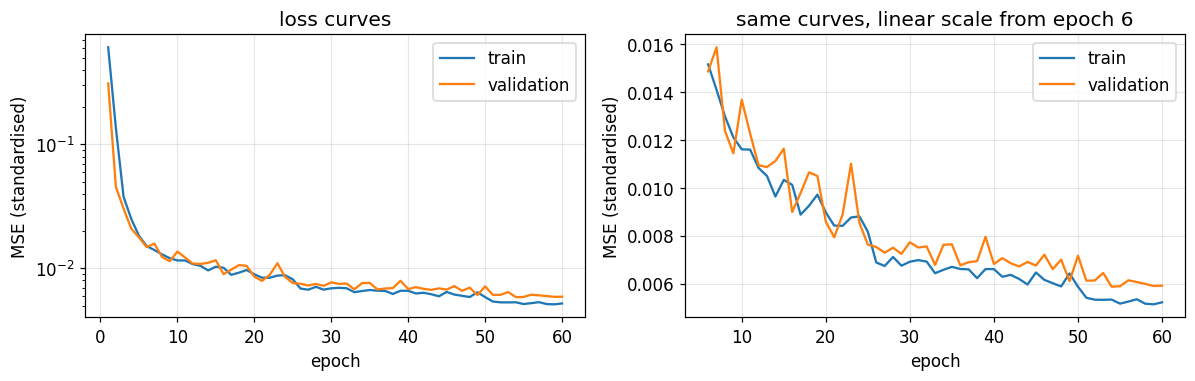

final train 0.00522   final val 0.00591
gap = +0.00070  -> the two curves sit on top of each other: no overfitting


In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ep = range(1, len(history["train"]) + 1)
ax[0].semilogy(ep, history["train"], label="train")
ax[0].semilogy(ep, history["val"],   label="validation")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE (standardised)")
ax[0].set_title("loss curves"); ax[0].legend()

ax[1].plot(ep[5:], history["train"][5:], label="train")
ax[1].plot(ep[5:], history["val"][5:],   label="validation")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("MSE (standardised)")
ax[1].set_title("same curves, linear scale from epoch 6"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"final train {history['train'][-1]:.5f}   final val {history['val'][-1]:.5f}")
print(f"gap = {history['val'][-1] - history['train'][-1]:+.5f}  "
      "-> the two curves sit on top of each other: no overfitting")

**How to read these curves** — this is the single most useful diagnostic you have:

| what you see | diagnosis | what to do |
|---|---|---|
| both high, flat | underfitting | bigger network, train longer, better features |
| train low, val much higher and rising | overfitting | more data, weight decay, dropout, early stopping |
| both low and together | good fit | stop; check against the noise floor |
| val spiky or exploding | learning rate too high | lower `lr`, or add a scheduler |

---
## 8. Does it actually work? The held-out test set

We look at the test set once. Three numbers matter:

1. **RMSE in newton-metres** — the engineering unit, not a standardised loss;
2. **the linear baseline** — if a straight line does as well, the network was not needed;
3. **the noise floor** — the torque sensor itself has ≈6 % noise, so no model can do better.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model.eval()
with torch.no_grad():
    pred_mlp = denorm_y(model(Xte_t).cpu().numpy())

linear   = LinearRegression().fit(Xtr, ytr)
pred_lin = linear.predict(Xte)

rmse = lambda p: np.sqrt(((p - yte)**2).mean(0))
rm_mlp, rm_lin = rmse(pred_mlp), rmse(pred_lin)
r2_mlp = r2_score(yte, pred_mlp, multioutput="raw_values")
r2_lin = r2_score(yte, pred_lin, multioutput="raw_values")
noise  = TAU_NOISE * y.std(0)

print(f"{'':14s}{'tau1 RMSE':>11s}{'tau2 RMSE':>11s}{'tau1 R2':>10s}{'tau2 R2':>10s}")
print(f"{'linear':14s}{rm_lin[0]:11.3f}{rm_lin[1]:11.3f}{r2_lin[0]:10.4f}{r2_lin[1]:10.4f}")
print(f"{'MLP':14s}{rm_mlp[0]:11.3f}{rm_mlp[1]:11.3f}{r2_mlp[0]:10.4f}{r2_mlp[1]:10.4f}")
print(f"{'noise floor':14s}{noise[0]:11.3f}{noise[1]:11.3f}")
print(f"\nthe MLP cuts shoulder-torque error by {rm_lin[0]/rm_mlp[0]:.1f}x "
      f"and sits {rm_mlp[0]/noise[0]:.2f}x above the sensor noise floor")

                tau1 RMSE  tau2 RMSE   tau1 R2   tau2 R2
linear              4.859      2.021    0.3364    0.2680
MLP                 0.439      0.178    0.9946    0.9943
noise floor         0.358      0.142

the MLP cuts shoulder-torque error by 11.1x and sits 1.23x above the sensor noise floor


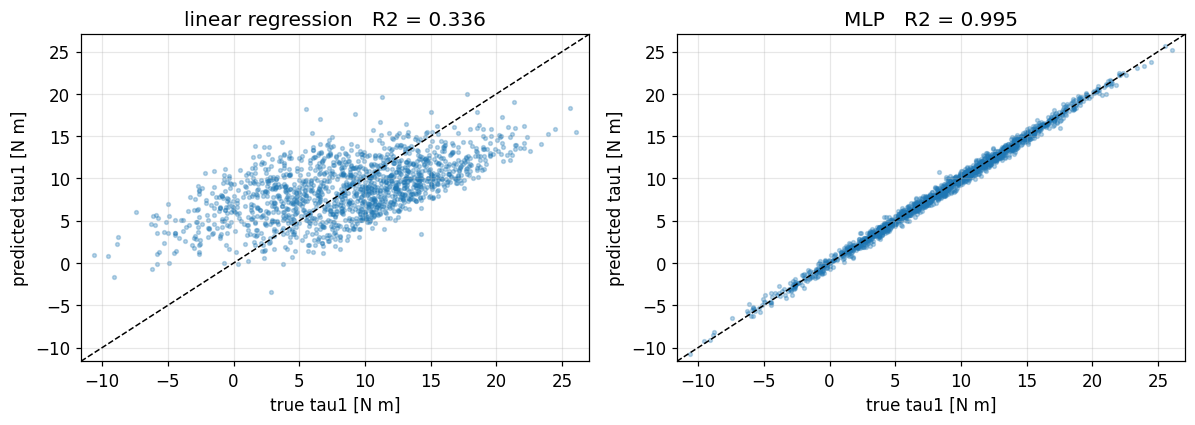

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.0))
lim = (yte[:, 0].min() - 1, yte[:, 0].max() + 1)
for a, p, ttl, r2v in [(ax[0], pred_lin, "linear regression", r2_lin[0]),
                       (ax[1], pred_mlp, "MLP",               r2_mlp[0])]:
    a.plot(lim, lim, "k--", lw=1)
    a.scatter(yte[:, 0], p[:, 0], s=6, alpha=0.3)
    a.set_xlim(lim); a.set_ylim(lim)
    a.set_xlabel("true tau1 [N m]"); a.set_ylabel("predicted tau1 [N m]")
    a.set_title(f"{ttl}   R2 = {r2v:.3f}")
plt.tight_layout(); plt.show()

### The test that a control engineer actually cares about

Random samples are one thing; a *trajectory* is another. Below we generate a smooth pick-and-place
move the network has never seen and ask it for the feed-forward torque at every instant.

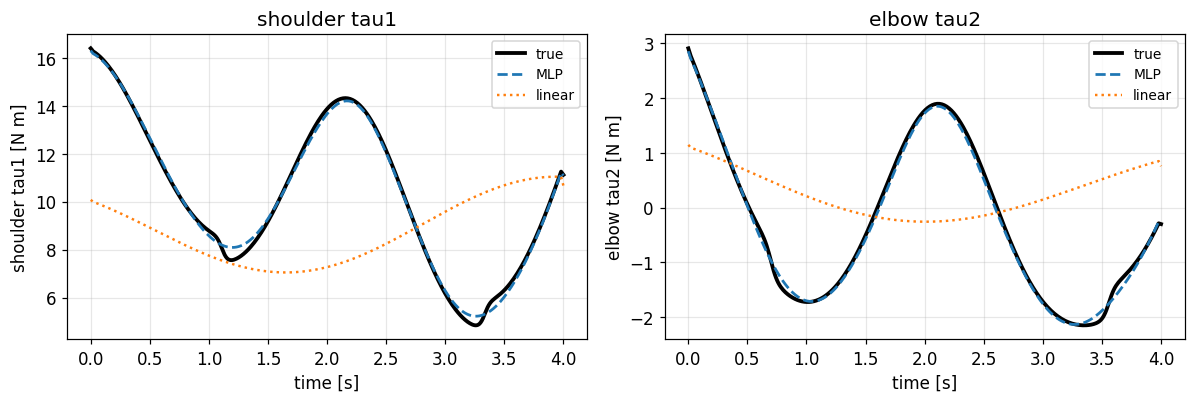

trajectory RMSE   MLP [0.18  0.077]   linear [4.015 1.584]  [N m]


In [15]:
t = np.linspace(0, 4, 400)
q1 = 0.9*np.sin(0.9*np.pi*t/2) - 0.2
q2 = 1.3*np.sin(0.7*np.pi*t/2 + 0.8)
dt = t[1] - t[0]
qd1, qd2   = np.gradient(q1, dt), np.gradient(q2, dt)
qdd1, qdd2 = np.gradient(qd1, dt), np.gradient(qd2, dt)

X_traj = np.column_stack([q1, q2, qd1, qd2, qdd1, qdd2]).astype(np.float32)
tau_true = np.column_stack(inverse_dynamics(q1, q2, qd1, qd2, qdd1, qdd2))

with torch.no_grad():
    tau_mlp = denorm_y(model(torch.tensor(norm_x(X_traj), device=device)).cpu().numpy())
tau_lin = linear.predict(X_traj)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for j, name in enumerate(["shoulder tau1", "elbow tau2"]):
    ax[j].plot(t, tau_true[:, j], "k",  lw=2.5, label="true")
    ax[j].plot(t, tau_mlp[:, j],  "--", lw=1.8, label="MLP")
    ax[j].plot(t, tau_lin[:, j],  ":",  lw=1.6, label="linear")
    ax[j].set_xlabel("time [s]"); ax[j].set_ylabel(f"{name} [N m]")
    ax[j].set_title(name); ax[j].legend(fontsize=9)
plt.tight_layout(); plt.show()

traj_rmse_mlp = np.sqrt(((tau_mlp - tau_true)**2).mean(0))
traj_rmse_lin = np.sqrt(((tau_lin - tau_true)**2).mean(0))
print(f"trajectory RMSE   MLP {traj_rmse_mlp.round(3)}   linear {traj_rmse_lin.round(3)}  [N m]")

---
## 9. Save, load, deploy

The trained network is worth nothing until it runs on the controller. **Save the `state_dict`, not
the model object** — `torch.save(model)` pickles your class definition along with the weights, so
the file breaks the moment you rename a file or refactor `ArmMLP`.

On the robot: rebuild the architecture, load the weights, call `.eval()`, and wrap inference in
`torch.no_grad()`. The normalisation constants are part of the model — save them too, or your
deployed network silently receives garbage.

In [16]:
ckpt = {
    "state_dict": model.state_dict(),
    "arch": {"n_in": 6, "n_hidden": 64, "n_out": 2},
    "x_mu": x_mu, "x_sd": x_sd, "y_mu": y_mu, "y_sd": y_sd,   # NEVER forget these
    "features": FEATURES, "targets": TARGETS,
    "test_rmse_Nm": rm_mlp.tolist(),
}
torch.save(ckpt, "arm_mlp.pt")
import os
print(f"saved arm_mlp.pt  ({os.path.getsize('arm_mlp.pt')/1024:.1f} KB)")
print("\nkeys in state_dict:")
for k, v in model.state_dict().items():
    print(f"  {k:12s} {tuple(v.shape)}")

saved arm_mlp.pt  (21.8 KB)

keys in state_dict:
  fc1.weight   (64, 6)
  fc1.bias     (64,)
  fc2.weight   (64, 64)
  fc2.bias     (64,)
  fc3.weight   (2, 64)
  fc3.bias     (2,)


In [17]:
# ---- what the controller does at boot ----
loaded = torch.load("arm_mlp.pt", weights_only=False)
robot_model = ArmMLP(**loaded["arch"]).to(device)
robot_model.load_state_dict(loaded["state_dict"])
robot_model.eval()                                     # inference mode

xm, xs = loaded["x_mu"], loaded["x_sd"]
ym, ys = loaded["y_mu"], loaded["y_sd"]


def feedforward_torque(q1, q2, qd1, qd2, qdd1, qdd2):
    '''One control-loop call: joint state in, motor torques out.'''
    s = np.array([[q1, q2, qd1, qd2, qdd1, qdd2]], dtype=np.float32)
    with torch.no_grad():
        out = robot_model(torch.tensor((s - xm)/xs, device=device)).cpu().numpy()
    return out[0]*ys + ym


demo = (0.35, -0.80, 1.10, -0.60, 2.5, -1.8)
print("predicted torques:", np.round(feedforward_torque(*demo), 3), "N m")
print("true torques     :", np.round(np.array(inverse_dynamics(*demo)), 3), "N m")

# reloaded model must be bit-identical to the trained one
with torch.no_grad():
    same_out = robot_model(Xte_t[:200]).cpu().numpy()
    orig_out = model(Xte_t[:200]).cpu().numpy()
print(f"\nmax |reloaded - original| = {np.abs(same_out - orig_out).max():.2e}   (should be 0)")

predicted torques: [17.908  2.071] N m
true torques     : [17.964  2.16 ] N m

max |reloaded - original| = 0.00e+00   (should be 0)


In [18]:
# Is it fast enough for a 1 kHz control loop?
one = Xte_t[:1]
with torch.no_grad():
    for _ in range(100):
        robot_model(one)                       # warm-up
    t0 = time.time()
    for _ in range(2000):
        robot_model(one)
    micros = (time.time() - t0)/2000 * 1e6

print(f"single-sample forward pass: {micros:.0f} us on {device}")
print(f"a 1 kHz control loop has 1000 us per cycle -> {micros/1000*100:.1f} % of the budget")

single-sample forward pass: 45 us on cpu
a 1 kHz control loop has 1000 us per cycle -> 4.5 % of the budget


---
## 10. The protocol — what to remember

1. **Split first, standardise with training statistics only.** Every leak flatters your numbers.
2. **The first axis is the batch.** Print `.shape` the moment anything is surprising.
3. **`zero_grad` → `forward` → `backward` → `step`.** In that order, every time.
4. **No activation on a regression output layer.**
5. **Watch train *and* validation loss.** Together and low = done. Apart and diverging =
   overfitting. Both high = underfitting.
6. **Compare against a dumb baseline and against the noise floor.** A network that only ties a
   linear fit is a network you did not need; a network at the noise floor cannot be improved with
   more training.
7. **Test set once, at the end.**
8. **Ship the `state_dict` plus the normalisation constants**, load with `.eval()`, infer under
   `torch.no_grad()`.

---
## 11. Exercises

1. **ReLU vs tanh.** Swap `nn.Tanh()` for `nn.ReLU()` in `ArmMLP` and retrain with the same seed.
   Compare final validation loss, test RMSE and wall-clock time. Then plot the network's
   prediction along the $q_2$ sweep from §5 — can you see the piecewise-linear kinks that ReLU
   produces, and do they matter for a torque command?

2. **Capacity sweep.** Train `n_hidden` ∈ {4, 8, 16, 64, 256} for 60 epochs each and plot final
   train and validation loss against width on a log-x axis. Where does underfitting stop? Does
   the widest network overfit — and if not, why not?

3. **Data efficiency.** Retrain on 250, 500, 1000, 2000 and 6000 training samples and plot test
   RMSE against training-set size. How much logged robot time would you actually need to buy the
   accuracy you have here?

4. **Break the standardisation.** Train on raw (unstandardised) inputs and targets with the same
   learning rate. Describe exactly how it fails and explain why in terms of the first gradient.

5. **Forget `zero_grad`.** Comment out `optimizer.zero_grad()` and train for 5 epochs. Print the
   norm of `fc1.weight.grad` at each step and explain the pattern you see.

6. **Physics-informed features.** Add $\cos q_2$, $\sin q_2$, $\cos(q_1+q_2)$, $\dot q_1\dot q_2$
   and $\dot q_2^2$ as extra input columns (11 features). Retrain the *linear* model on these.
   How close does it get to the MLP? What does that tell you about what the hidden layers are
   doing?

7. **Extrapolation.** Build a test set with $|\dot q_1| \in [3, 5]$ rad/s — well outside the
   training distribution — and evaluate. Neural networks interpolate well and extrapolate badly:
   quantify how badly, and say what that means for the safety case for putting this on a real arm.

8. **A residual model.** Real practice rarely learns the whole map. Compute the rigid-body torque
   from the *nominal* model (say, with link masses 10 % wrong) and train the network on the
   **residual** between that and the measured torque. Compare the accuracy and the size of network
   you need against the end-to-end model here.

---
## 12. References

**Method**

- Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by
  back-propagating errors.* **Nature** 323, 533–536. — the paper that made backpropagation
  standard.
- Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic Optimization.* **ICLR 2015**. —
  the optimiser used throughout this notebook.
- Glorot, X. & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward
  neural networks.* **AISTATS 2010**. — where PyTorch's default `Linear` initialisation comes
  from.
- Hornik, K., Stinchcombe, M. & White, H. (1989). *Multilayer feedforward networks are universal
  approximators.* **Neural Networks** 2(5), 359–366. — why one hidden layer is enough in
  principle, and why depth still helps in practice.
- Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning*, MIT Press. Chapters 6
  (feedforward networks) and 8 (optimisation).

**Robotics application**

- Nguyen-Tuong, D. & Peters, J. (2011). *Model learning for robot control: a survey.*
  **Cognitive Processing** 12(4), 319–340.
- Lutter, M., Ritter, C. & Peters, J. (2019). *Deep Lagrangian Networks: Using Physics as Model
  Prior for Deep Learning.* **ICLR 2019**. — the physics-informed version of exercise 8.
- Siciliano, B., Sciavicco, L., Villani, L. & Oriolo, G. (2009). *Robotics: Modelling, Planning
  and Control*, Springer. Chapter 7 — the rigid-body dynamics used to generate the data here.

**Software**

- PyTorch documentation — https://pytorch.org/docs/stable/index.html
- *Learn the Basics* tutorial — https://pytorch.org/tutorials/beginner/basics/intro.html
- Autograd mechanics — https://pytorch.org/docs/stable/notes/autograd.html
- `torch.utils.data` — https://pytorch.org/docs/stable/data.html

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>